<a href="https://colab.research.google.com/github/krishnagaadha9/churn-prediction-project/blob/main/churn_prediction_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost


In [2]:
from google.colab import files
uploaded = files.upload()  # A button will appear — click it and upload BankChurners.csv


Saving BankChurners.csv to BankChurners.csv


In [6]:
# Step 1 — install and load
!pip install jupysql -q

# Step 2 — imports
import pandas as pd
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Step 3 — load CSV
df = pd.read_csv('BankChurners.csv')
df = df.iloc[:, :-2]
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset shape: (10127, 21)
Columns: ['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


In [7]:
%load_ext sql
%sql sqlite://

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [8]:
%sql --persist df

Running query in 'sqlite://'

Success! Persisted df to the database.

In [9]:
%%sql
SELECT COUNT(*) as total_rows FROM df

Running query in 'sqlite://'

total_rows
10127


In [10]:
%%sql
SELECT
    COUNT(*) as total_customers,
    SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) as churned,
    SUM(CASE WHEN Attrition_Flag = 'Existing Customer' THEN 1 ELSE 0 END) as retained,
    ROUND(SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as churn_rate_pct
FROM df

Running query in 'sqlite://'

total_customers,churned,retained,churn_rate_pct
10127,1627,8500,16.07


In [11]:
%%sql
SELECT
    Attrition_Flag,
    ROUND(AVG(Customer_Age), 1) as avg_age,
    ROUND(AVG(Total_Trans_Ct), 1) as avg_transactions,
    ROUND(AVG(Total_Trans_Amt), 1) as avg_amount,
    ROUND(AVG(Months_Inactive_12_mon), 1) as avg_inactive_months,
    ROUND(AVG(Credit_Limit), 1) as avg_credit_limit
FROM df
GROUP BY Attrition_Flag

Running query in 'sqlite://'

Attrition_Flag,avg_age,avg_transactions,avg_amount,avg_inactive_months,avg_credit_limit
Attrited Customer,46.7,44.9,3095.0,2.7,8136.0
Existing Customer,46.3,68.7,4654.7,2.3,8726.9


In [12]:
%%sql
SELECT
    Gender,
    COUNT(*) as total,
    SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) as churned,
    ROUND(SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as churn_rate_pct
FROM df
GROUP BY Gender
ORDER BY churn_rate_pct DESC

Running query in 'sqlite://'

Gender,total,churned,churn_rate_pct
F,5358,930,17.36
M,4769,697,14.62


In [13]:
%%sql
SELECT
    Education_Level,
    COUNT(*) as total,
    SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) as churned,
    ROUND(SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as churn_rate_pct
FROM df
GROUP BY Education_Level
ORDER BY churn_rate_pct DESC

Running query in 'sqlite://'

Education_Level,total,churned,churn_rate_pct
Doctorate,451,95,21.06
Post-Graduate,516,92,17.83
Unknown,1519,256,16.85
Uneducated,1487,237,15.94
Graduate,3128,487,15.57
High School,2013,306,15.2
College,1013,154,15.2


In [14]:
%%sql
SELECT
    CASE
        WHEN Customer_Age < 30 THEN 'Under 30'
        WHEN Customer_Age BETWEEN 30 AND 45 THEN '30-45'
        WHEN Customer_Age BETWEEN 46 AND 60 THEN '46-60'
        ELSE 'Over 60'
    END as age_group,
    COUNT(*) as total,
    ROUND(SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as churn_rate_pct
FROM df
GROUP BY age_group
ORDER BY churn_rate_pct DESC

Running query in 'sqlite://'

age_group,total,churn_rate_pct
46-60,5061,16.62
30-45,4466,15.92
Over 60,405,14.32
Under 30,195,8.72


In [15]:
%%sql
SELECT
    Card_Category,
    COUNT(*) as total,
    SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) as churned,
    ROUND(AVG(Credit_Limit), 2) as avg_credit_limit,
    ROUND(SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as churn_rate_pct
FROM df
GROUP BY Card_Category
ORDER BY churn_rate_pct DESC

Running query in 'sqlite://'

Card_Category,total,churned,avg_credit_limit,churn_rate_pct
Platinum,20,5,30283.45,25.0
Gold,116,21,28416.37,18.1
Blue,9436,1519,7363.78,16.1
Silver,555,82,25277.84,14.77


In [21]:
# Run this in a Python cell
churned = df[df['Attrition_Flag'] == 'Attrited Customer']
retained = df[df['Attrition_Flag'] == 'Existing Customer']

cols = ['Total_Trans_Ct', 'Months_Inactive_12_mon',
        'Total_Trans_Amt', 'Credit_Limit']

for col in cols:
    print(f"\n--- {col} ---")
    print(f"Churned   | 25th: {churned[col].quantile(0.25):.1f} | "
          f"50th: {churned[col].quantile(0.50):.1f} | "
          f"75th: {churned[col].quantile(0.75):.1f}")
    print(f"Retained  | 25th: {retained[col].quantile(0.25):.1f} | "
          f"50th: {retained[col].quantile(0.50):.1f} | "
          f"75th: {retained[col].quantile(0.75):.1f}")


--- Total_Trans_Ct ---
Churned   | 25th: 37.0 | 50th: 43.0 | 75th: 51.0
Retained  | 25th: 54.0 | 50th: 71.0 | 75th: 82.0

--- Months_Inactive_12_mon ---
Churned   | 25th: 2.0 | 50th: 3.0 | 75th: 3.0
Retained  | 25th: 1.0 | 50th: 2.0 | 75th: 3.0

--- Total_Trans_Amt ---
Churned   | 25th: 1903.5 | 50th: 2329.0 | 75th: 2772.0
Retained  | 25th: 2384.8 | 50th: 4100.0 | 75th: 4781.2

--- Credit_Limit ---
Churned   | 25th: 2114.0 | 50th: 4178.0 | 75th: 9933.5
Retained  | 25th: 2602.0 | 50th: 4643.5 | 75th: 11252.8


In [22]:
%%sql
SELECT
    Customer_Age,
    Gender,
    Card_Category,
    Months_Inactive_12_mon,
    Total_Trans_Ct,
    Total_Trans_Amt,
    Credit_Limit,
    Attrition_Flag
FROM df
WHERE Total_Trans_Ct < 51
AND Total_Trans_Amt < 2772
AND Months_Inactive_12_mon >= 3
ORDER BY Total_Trans_Ct ASC
LIMIT 20

Running query in 'sqlite://'

Customer_Age,Gender,Card_Category,Months_Inactive_12_mon,Total_Trans_Ct,Total_Trans_Amt,Credit_Limit,Attrition_Flag
59,M,Blue,3,10,530,14979.0,Attrited Customer
32,M,Blue,3,10,695,22382.0,Attrited Customer
33,M,Blue,3,10,741,8925.0,Attrited Customer
57,M,Blue,3,11,678,8249.0,Attrited Customer
40,M,Blue,3,11,975,6884.0,Existing Customer
55,F,Blue,4,12,615,2158.0,Attrited Customer
60,F,Blue,4,12,702,1438.3,Attrited Customer
37,M,Blue,3,12,694,3100.0,Attrited Customer
58,M,Blue,4,13,715,1438.3,Attrited Customer
37,M,Blue,3,13,862,6866.0,Attrited Customer


In [23]:
%%sql
SELECT
    CASE
        WHEN Credit_Limit < 5000 THEN 'Low under 5k'
        WHEN Credit_Limit BETWEEN 5000 AND 15000 THEN 'Mid 5k-15k'
        ELSE 'High over 15k'
    END as credit_bucket,
    COUNT(*) as total,
    ROUND(SUM(CASE WHEN Attrition_Flag = 'Attrited Customer' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as churn_rate_pct
FROM df
GROUP BY credit_bucket
ORDER BY churn_rate_pct DESC

Running query in 'sqlite://'

credit_bucket,total,churn_rate_pct
Low under 5k,5358,17.28
Mid 5k-15k,2956,15.12
High over 15k,1813,14.01


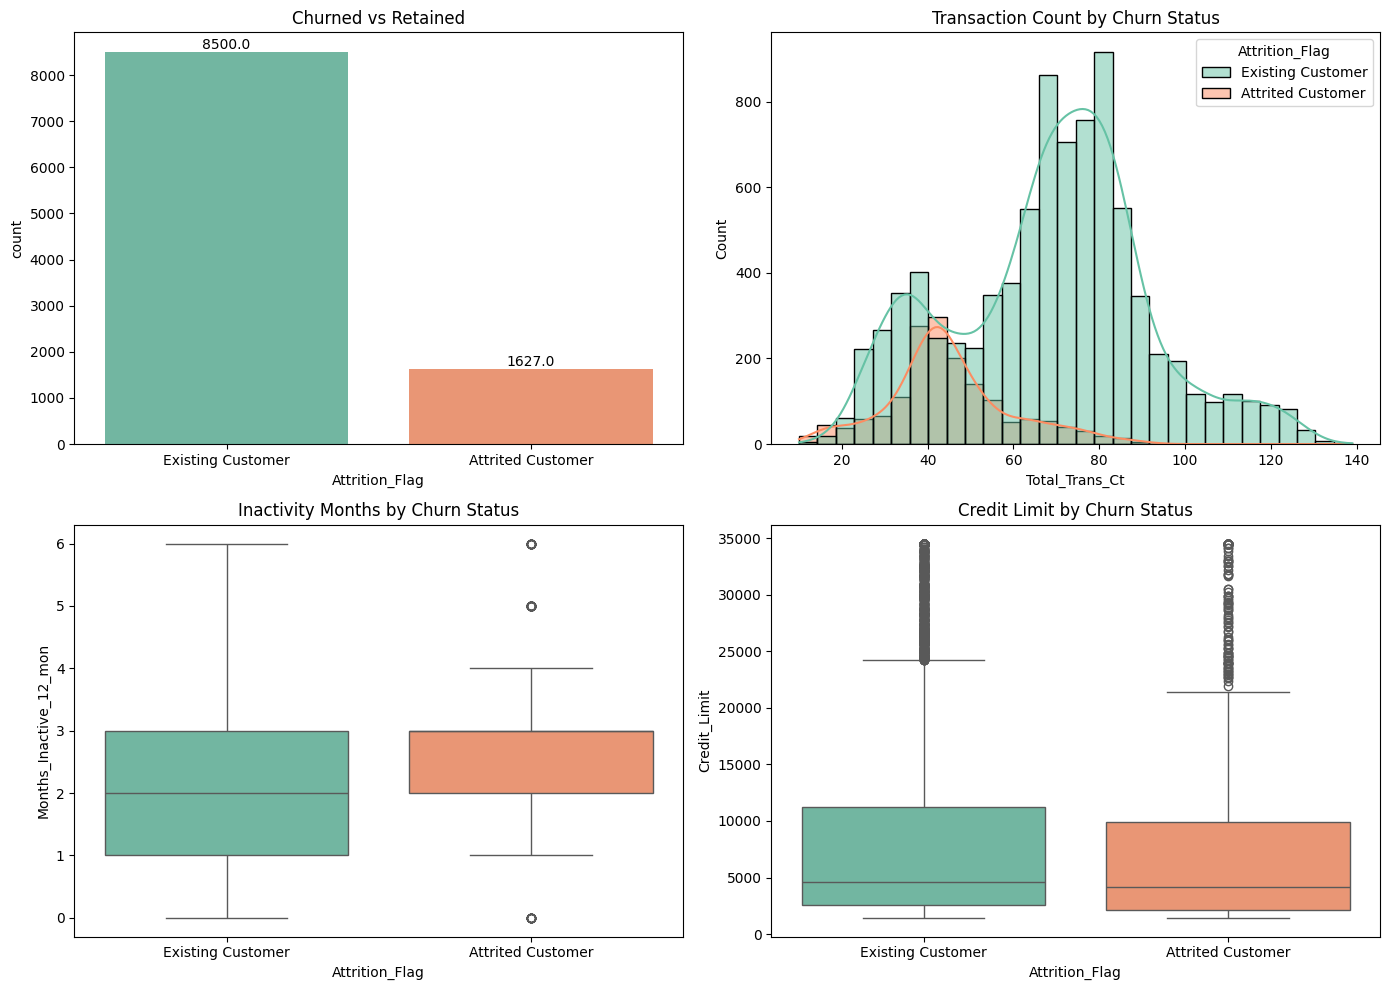

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Churn distribution
sns.countplot(x='Attrition_Flag', data=df,
              palette='Set2', ax=axes[0,0])
axes[0,0].set_title('Churned vs Retained')
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{p.get_height()}',
                       (p.get_x() + p.get_width()/2, p.get_height()),
                       ha='center', va='bottom')

# 2. Transaction count by churn
sns.histplot(data=df, x='Total_Trans_Ct',
             hue='Attrition_Flag', bins=30,
             kde=True, palette='Set2', ax=axes[0,1])
axes[0,1].set_title('Transaction Count by Churn Status')

# 3. Inactivity by churn
sns.boxplot(x='Attrition_Flag', y='Months_Inactive_12_mon',
            data=df, palette='Set2', ax=axes[1,0])
axes[1,0].set_title('Inactivity Months by Churn Status')

# 4. Credit limit by churn
sns.boxplot(x='Attrition_Flag', y='Credit_Limit',
            data=df, palette='Set2', ax=axes[1,1])
axes[1,1].set_title('Credit Limit by Churn Status')

plt.tight_layout()
plt.show()

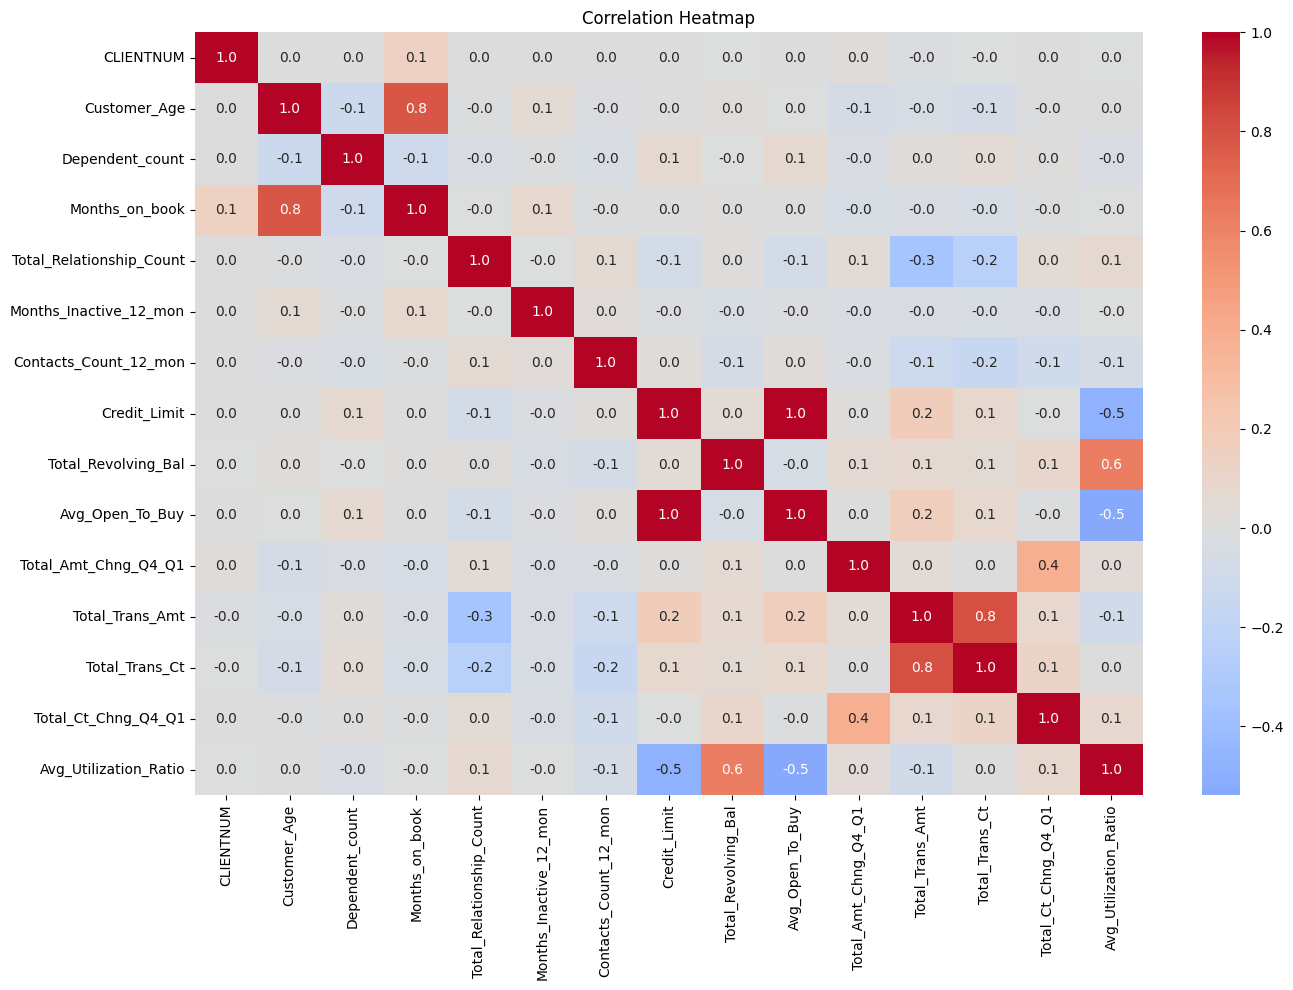

In [25]:
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(),
            annot=True, fmt='.1f',
            cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()